In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
import matplotlib.dates as mdates
from matplotlib.dates import DateFormatter
import mlflow
import os


In [2]:
df = pd.read_csv('data/train_ver2.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')
# Общая информация
print(df.info(show_counts=True)) 

C:\Users\Admin\AppData\Local\Temp\ipykernel_24072\2562583876.py:1: DtypeWarning: Columns (5,8,11,15) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/train_ver2.csv')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13647309 entries, 0 to 13647308
Data columns (total 48 columns):
 #   Column                 Non-Null Count     Dtype  
---  ------                 --------------     -----  
 0   fecha_dato             13647309 non-null  object 
 1   ncodpers               13647309 non-null  int64  
 2   ind_empleado           13619575 non-null  object 
 3   pais_residencia        13619575 non-null  object 
 4   sexo                   13619505 non-null  object 
 5   age                    13647309 non-null  object 
 6   fecha_alta             13619575 non-null  object 
 7   ind_nuevo              13619575 non-null  float64
 8   antiguedad             13647309 non-null  object 
 9   indrel                 13619575 non-null  float64
 10  ult_fec_cli_1t         24793 non-null     object 
 11  indrel_1mes            13497528 non-null  object 
 12  tiprel_1mes            13497528 non-null  object 
 13  indresi                13619575 non-null  object 
 14  

1. Первичный анализ данных

In [3]:
with open('columns.txt', 'r', encoding='utf-8') as file:
    content = file.read().strip()  # Читаем содержимое и удаляем пробелы по краям
    items = [item.strip() for item in content.split(';') if item.strip()]

In [4]:
cool_names_dict = dict(zip(list(df.columns),items))

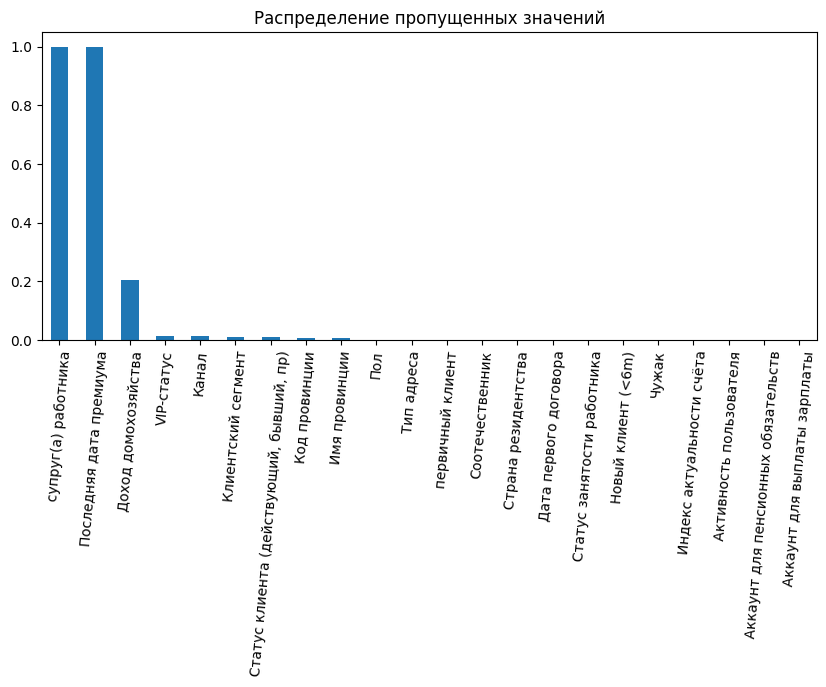

In [5]:
# Пропуски в данных
missing = df.isna().mean().sort_values(ascending=False)
missing = missing[missing>0]
labels = missing.index.tolist()
cool_labels =[cool_names_dict[label] for label in labels]
missing[missing > 0].plot(kind='bar', figsize=(10, 4))
#set x axis labels to labels list
plt.xticks(range(len(cool_labels)), cool_labels, rotation=85)
plt.title('Распределение пропущенных значений')
plt.show()

Вывод: пропуски распределены неравномерно. Большинство признаков заполнено почти полностью, но `conyuemp` и `ult_fec_cli_1t` практически неинформативны из-за большого числа пропусков, а `renta` требует аккуратного заполнения и клиппинга. В обучающем пайплайне это закрывается медианами/модами, рассчитанными только на train-части.


1.1 Анализ временных данных

In [6]:
# Преобразование в datetime с обработкой ошибок
df['fecha_alta'] = pd.to_datetime(df['fecha_alta'], errors='coerce')
df['ult_fec_cli_1t'] = pd.to_datetime(df['ult_fec_cli_1t'], errors='coerce')

# 1. Анализ временного диапазона и пропусков
for time_col in ['fecha_alta', 'ult_fec_cli_1t']:
    print(f"Основная информация о датах /{cool_names_dict[time_col]}/:")
    print(f"Минимальная дата: {df[time_col].min().strftime('%Y-%m-%d')}")
    print(f"Максимальная дата: {df[time_col].max().strftime('%Y-%m-%d')}")
    print(f"Пропущенные значения: {df[time_col].isna().sum()} ({df[time_col].isna().mean():.1%})")

Основная информация о датах /Дата первого договора/:
Минимальная дата: 1995-01-16
Максимальная дата: 2016-05-31
Пропущенные значения: 27734 (0.2%)
Основная информация о датах /Последняя дата премиума/:
Минимальная дата: 2015-07-01
Максимальная дата: 2016-05-30
Пропущенные значения: 13622516 (99.8%)


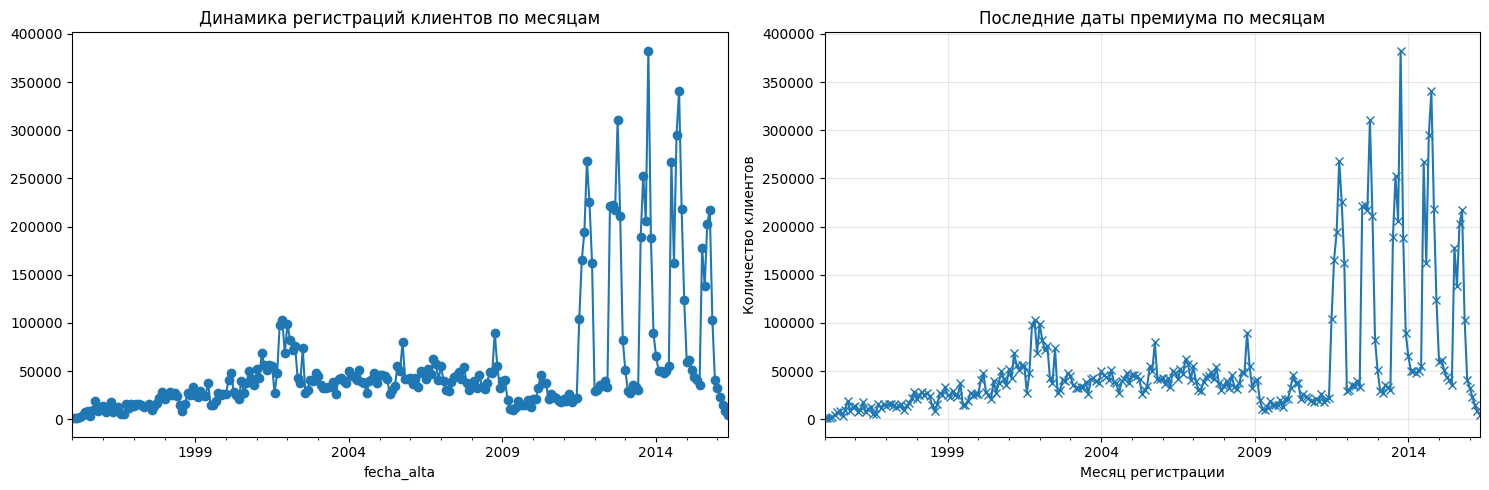

In [7]:
# 2. Визуализация распределения по месяцам
fig, ax = plt.subplots(1,2, figsize=(15, 5))
df['fecha_alta'].dt.to_period('M').value_counts().sort_index().plot(
    kind='line', 
    marker='o',
    title='Динамика регистраций клиентов по месяцам',
    ax=ax[0]
)
df['ult_fec_cli_1t'].dt.to_period('M').value_counts().sort_index().plot(
    kind='line', 
    marker='x',
    title='Последние даты премиума по месяцам',
    ax=ax[1]
)
plt.xlabel('Месяц регистрации')
plt.ylabel('Количество клиентов')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
def create_time_cohorts(series, max_cohorts=30):
    """
    Разделяет временной ряд на когорты с примерно равным количеством элементов
    
    Параметры:
        series (pd.Series): Временной ряд с датами
        max_cohorts (int): Максимальное количество когорт
    
    Возвращает:
        pd.Series: Метки когорт для каждого наблюдения
    """
    # Преобразуем даты в числовой формат (дни с минимальной даты)
    base_date = series.min()
    days_since = (series - base_date).dt.days
    
    # Автоматический подбор количества когорт
    n_cohorts = min(max_cohorts, len(series.unique()))
    
    # Разбиение на когорты с проверкой дубликатов
    try:
        cohorts = pd.qcut(
            days_since,
            q=n_cohorts,
            precision=0,
            duplicates='drop'
        )
    except ValueError:
        # Если невозможно разбить на запрошенное количество когорт
        n_cohorts = len(series.unique())
        cohorts = pd.qcut(
            days_since,
            q=n_cohorts,
            precision=0,
            duplicates='drop'
        )
    
    # Преобразуем обратно в даты
    cohort_ranges = cohorts.apply(
        lambda x: pd.Interval(
            left=base_date + pd.Timedelta(days=x.left),
            right=base_date + pd.Timedelta(days=x.right),
            closed='right'
        )
    )
    
    return cohort_ranges

In [9]:
for time_col in ['fecha_alta', 'ult_fec_cli_1t']:
    df[time_col] = create_time_cohorts(df[time_col], max_cohorts=30)

1.2. Анализ количественных признаков

In [10]:
quantitative_cols = ['age','antiguedad','renta']
for col in quantitative_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [11]:
def analyze_numerical_features(df, namer, sample_size=10000):
    """
    Анализирует количественные признаки с автоматическим подбором визуализаций
    """
   
    # Сэмплирование данных для больших датасетов
    df_sample = df.sample(min(sample_size, len(df))) if len(df) > sample_size else df
    
    # Настройка стиля графиков
    plt.style.use('seaborn-v0_8-poster')
    sns.set_palette("husl")
    numeric_cols = [col for col in df.columns]
    # Анализ каждого признака
    for col in numeric_cols:
        print(f"\nАнализ признака: {namer[col]}")
        print("="*40)
        
        # Статистики
        data = np.array(df_sample[col].dropna())
        skewness = stats.skew(data)
        kurtosis = stats.kurtosis(data)
        
        print(f"Количество уникальных значений: { len(np.unique(data))}")
        print(f"Пропущенные значения: {df[col].isna().sum()}")
        print(f"Среднее: {data.mean():.2f}")
        print(f"Скошенность: {skewness:.2f}")
        print(f"Эксцесс: {kurtosis:.2f}")
        print(f"Описание:\n{df_sample[col].describe(percentiles=[0.25, 0.5, 0.75, 0.95, 0.99])}")
        
        # Создаем фигуру
        plt.figure(figsize=(16, 6))
        plt.suptitle(f'Анализ признака: {namer[col]}', y=1.02)
        
        # Гистограмма и плотность распределения
        plt.subplot(1, 3, 1)
        sns.histplot(data, kde=True)
        plt.title(f'Распределение ({len(np.unique(data))} unique)')
        plt.xlabel('')
        
        # Боксплот
        plt.subplot(1, 3, 2)
        sns.boxplot(x=data)
        plt.title(f'Выбросы (skew: {skewness:.2f})')
        plt.xlabel('')
        
        # Q-Q plot
        plt.subplot(1, 3, 3)
        stats.probplot(data, dist="norm", plot=plt)
        plt.title('Q-Q Plot')
        
        plt.tight_layout()
        plt.show()
    


Анализ признака: Возраст
Количество уникальных значений: 105
Пропущенные значения: 27734
Среднее: 40.29
Скошенность: 0.82
Эксцесс: 0.37
Описание:
count    9979.000000
mean       40.289708
std        17.350066
min         3.000000
25%        24.000000
50%        39.000000
75%        51.000000
95%        73.000000
99%        89.000000
max       164.000000
Name: age, dtype: float64


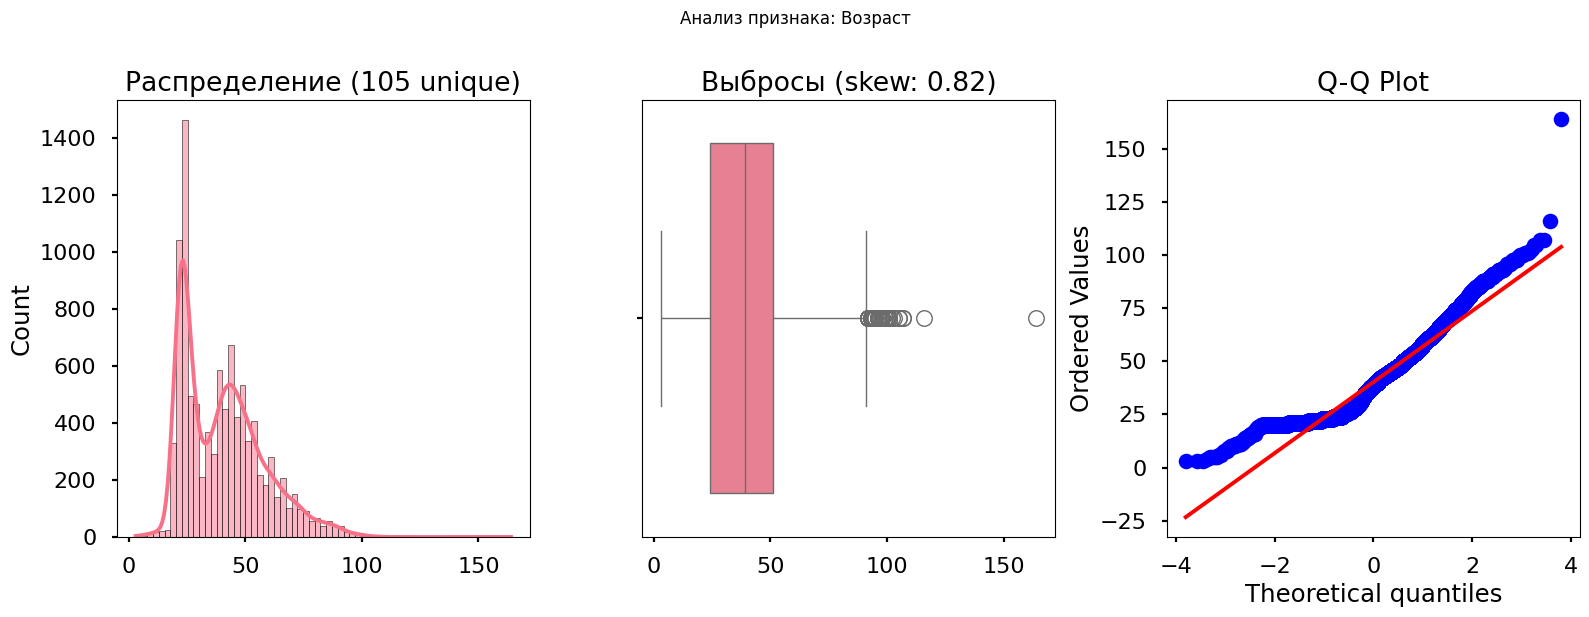


Анализ признака: Стаж клиента (в месяцах)
Количество уникальных значений: 254
Пропущенные значения: 27734
Среднее: 79.68
Скошенность: 0.63
Эксцесс: -0.91
Описание:
count    9979.000000
mean       79.682533
std        66.850329
min         0.000000
25%        22.000000
50%        50.000000
75%       138.000000
95%       202.000000
99%       232.000000
max       254.000000
Name: antiguedad, dtype: float64


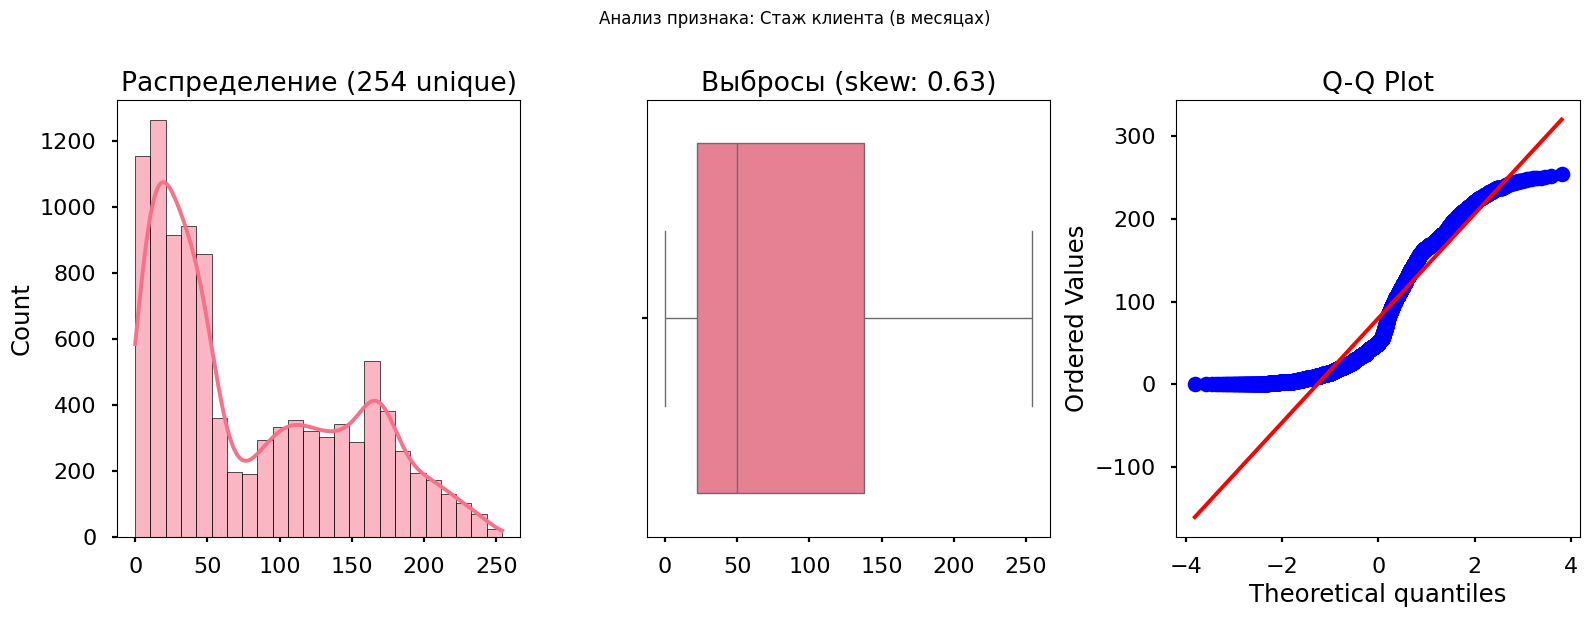


Анализ признака: Доход домохозяйства
Количество уникальных значений: 7848
Пропущенные значения: 2794375
Среднее: 136155.02
Скошенность: 32.83
Эксцесс: 1417.57
Описание:
count    7.975000e+03
mean     1.361550e+05
std      2.378505e+05
min      7.776000e+03
25%      6.929330e+04
50%      1.027807e+05
75%      1.559534e+05
95%      3.096686e+05
99%      5.719129e+05
max      1.185786e+07
Name: renta, dtype: float64


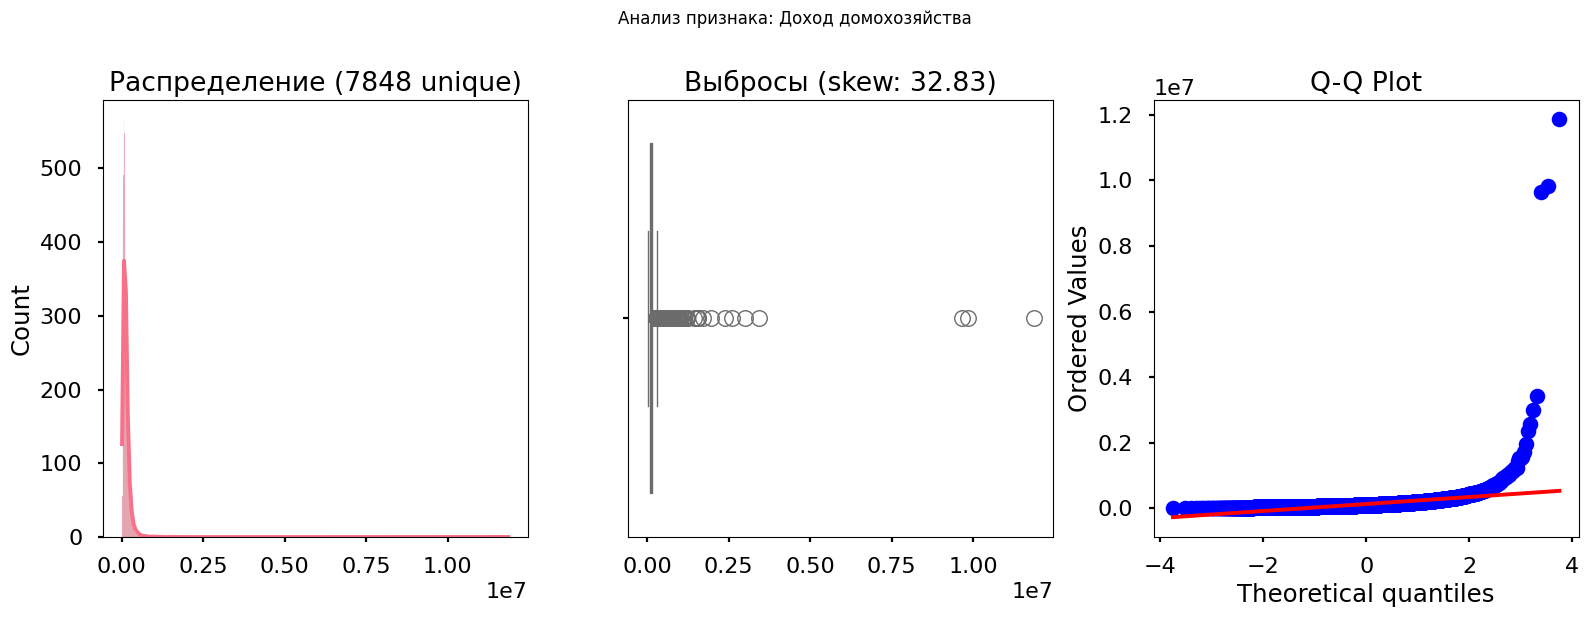

In [12]:
analyze_numerical_features(df[quantitative_cols], cool_names_dict)

**Выводы по числовым признакам**

1. `age`: есть выбросы и очень пожилые клиенты (до 164 лет), поэтому возраст переводится в устойчивые интервалы.
2. `antiguedad`: распределение неоднородное, с несколькими пиками стажа; признак используется как числовой и в производных отношениях с доходом.
3. `renta`: тяжёлый правый хвост и много пропусков. Для модели доход заполняется медианой train-части и клиппируется по квантилям, чтобы единичные сверхвысокие значения не доминировали.


1.3 Анализ категориальных признаков

In [13]:
products=['ind_ahor_fin_ult1',
'ind_aval_fin_ult1',
'ind_cco_fin_ult1',
'ind_cder_fin_ult1',
'ind_cno_fin_ult1',
'ind_ctju_fin_ult1',
'ind_ctma_fin_ult1',
'ind_ctop_fin_ult1',
'ind_ctpp_fin_ult1',
'ind_deco_fin_ult1',
'ind_deme_fin_ult1',
'ind_dela_fin_ult1',
'ind_ecue_fin_ult1',
'ind_fond_fin_ult1',
'ind_hip_fin_ult1',
'ind_plan_fin_ult1',
'ind_pres_fin_ult1',
'ind_reca_fin_ult1',
'ind_tjcr_fin_ult1',
'ind_valo_fin_ult1',
'ind_viv_fin_ult1',
'ind_nomina_ult1',
'ind_nom_pens_ult1',
'ind_recibo_ult1']


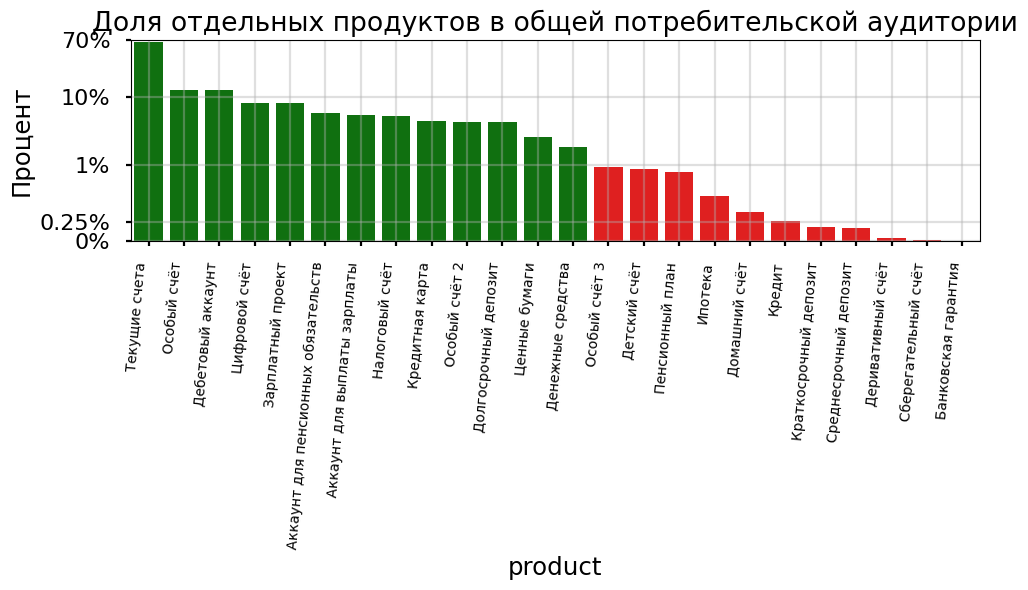

In [14]:
d = df[products].mean()*100
sorted_df = d.to_frame('Доля').sort_values(by='Доля', ascending=False)
p_list = sorted_df.index.tolist()

# Создаем DataFrame для Seaborn
plot_df = sorted_df.reset_index().rename(columns={'index': 'product'})
colors = ['red' if x < 1 else 'green' for x in plot_df['Доля']]

plt.figure(figsize=(10, 6))
sns.barplot(
    x='product',
    y='Доля',
    data=plot_df,
    palette=colors,
    hue = 'product',
    order=plot_df['product']  # Сохраняем сортировку
)

# Настраиваем подписи и оформление
plt.xticks(
    range(len(p_list)),
    [cool_names_dict[x] for x in p_list],
    rotation=85,
    ha='right',
    size=10
)
plt.ylabel('Процент')
plt.yscale('symlog', linthresh=1)
plt.yticks([0, 0.25, 1, 10, 70], ['0%','0.25%', '1%', '10%', '70%'])
plt.title('Доля отдельных продуктов в общей потребительской аудитории')
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

Потребление продуктов сильно неравномерно. Текущий счёт и несколько массовых продуктов покрывают основную долю клиентов, а многие продукты встречаются менее чем у 1% аудитории. Поэтому в `modeling.ipynb` целевые классы ограничены шорт-листом популярных покупок, а редкие продукты объединены в `other`.


In [15]:
# Оставим только продукты, преодолевшие порог статистической значимости в 5%
products =d[d>5].to_frame('Доля').sort_values(by='Доля', ascending=False).index.tolist()
# Выберем продукты-аутосайдеры, которые купили менее 0,25% клиентов
outsiders = d[d<0.25].to_frame('Доля').sort_values(by='Доля', ascending=False).index.tolist()


In [16]:
one_month_data = df[df['fecha_dato']=='2016-05-28']

In [17]:

def make_heatmap(df, f, dict, products):
    data = df[products+[f]].copy()
    # Группировка и агрегация данных
    heatmap_data = data.groupby(f).mean().T * 100  # Процентное представление

    # Визуализация
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".1f",
        cmap="YlGnBu",
        linewidths=.5,
        cbar_kws={'label': 'Доля приобретенных продуктов (%)'}
    )

    plt.title(f'Распределение продуктов по категориям {dict[f]}')
    plt.xlabel(dict[f])
    plt.ylabel('Список продуктов')
    plt.xticks(rotation=0, size=10)
    plt.tight_layout()
    plt.yticks(range(len(products)), [dict[x] for x in products], size=10)
    plt.show()

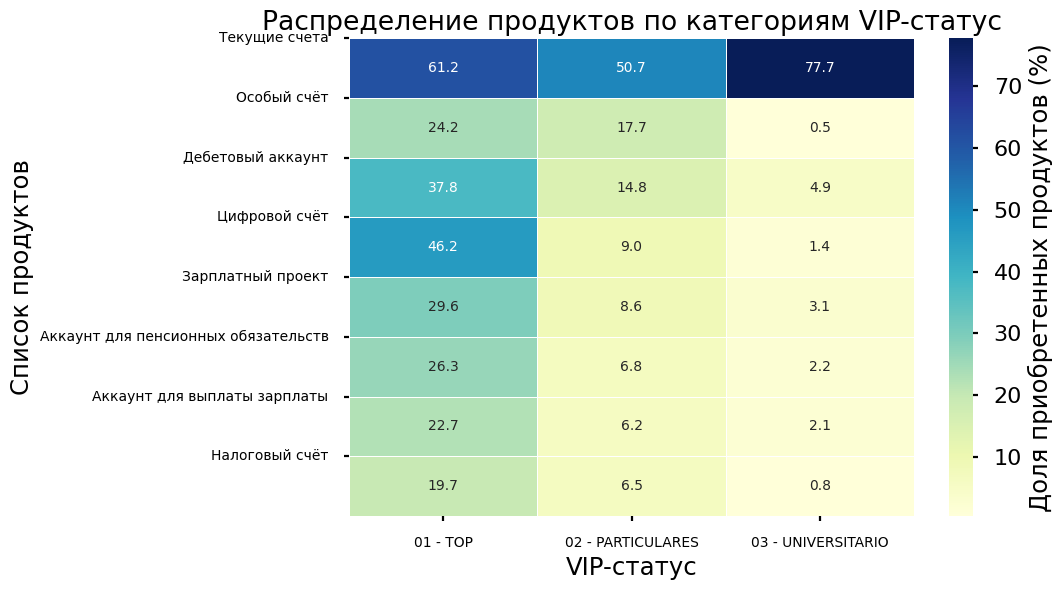

In [18]:
sub = df[df['fecha_dato']=='2015-12-28']
one_month_data = sub[products+['segmento']].copy()
make_heatmap(one_month_data, f='segmento', dict=cool_names_dict, products=products)

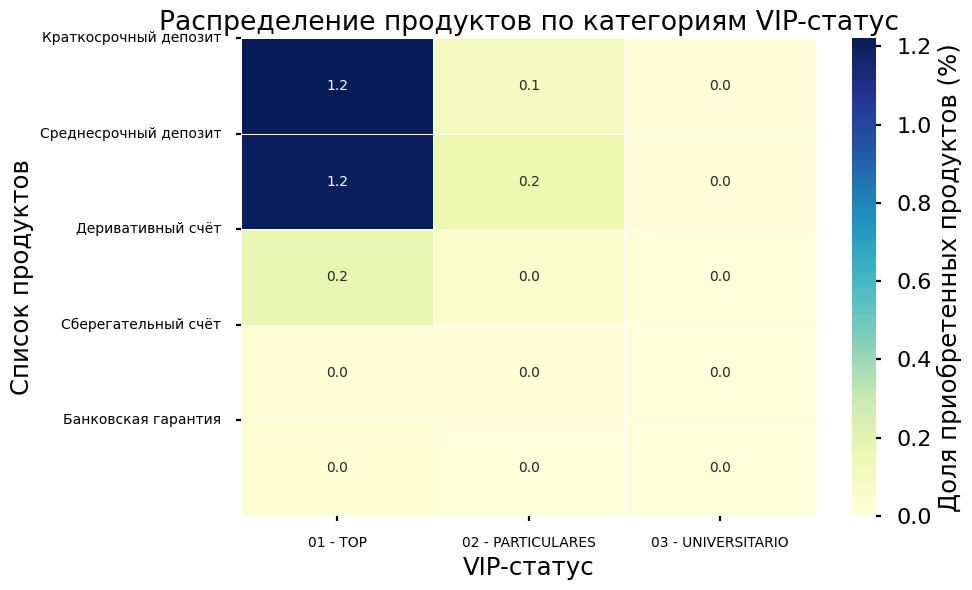

In [19]:
make_heatmap(sub, f='segmento', dict=cool_names_dict, products=outsiders)

In [20]:

for c in df.columns:
    print(cool_names_dict[c]+"*"*10)
    print(sub[c].value_counts(normalize=True))

Колонка для разделения таблицы**********
fecha_dato
2015-12-28    1.0
Name: proportion, dtype: float64
Идентификатор пользователя**********
ncodpers
1400556    0.000001
1017818    0.000001
1017819    0.000001
1017820    0.000001
1017821    0.000001
             ...   
298344     0.000001
1017829    0.000001
1017827    0.000001
1017825    0.000001
1017824    0.000001
Name: proportion, Length: 912021, dtype: float64
Статус занятости работника**********
ind_empleado
N    0.999430
B    0.000240
F    0.000167
A    0.000162
S    0.000001
Name: proportion, dtype: float64
Страна резидентства**********
pais_residencia
ES    0.995639
FR    0.000343
AR    0.000318
DE    0.000306
GB    0.000306
        ...   
BZ    0.000001
GM    0.000001
CD    0.000001
KZ    0.000001
JM    0.000001
Name: proportion, Length: 117, dtype: float64
Пол**********
sexo
V    0.541675
H    0.458325
Name: proportion, dtype: float64
Возраст**********
age
24.0     0.055350
23.0     0.055136
22.0     0.053448
21.0     0.05267

**Итоговые выводы EDA**

1. **Демография и география.** Клиентская база почти полностью испанская; крупнейшие провинции — Madrid и Barcelona. Возрастной профиль смещён к молодым клиентам, но есть аномально высокие значения возраста.
2. **Активность.** Около 57.8% клиентов неактивны, а основные каналы привлечения сконцентрированы в нескольких кодах (`KHE`, `KAT`, `KFC`).
3. **Продукты.** Текущий счёт доминирует; большинство остальных продуктов редкие. Это создаёт сильный дисбаланс классов в рекомендательной задаче.
4. **Качество данных.** Требуются заполнение пропусков, клиппинг дохода/стажа, сворачивание редких категорий и исключение малоинформативных колонок.


Для моделирования используется следующая стратегия: заполнить пропуски, обработать выбросы, свернуть редкие категории, удалить малоинформативные признаки и обучить все параметры предобработки только на train-части. Эта логика реализована в `preprocessing.py` и переиспользуется сервисом.


1.4 Анализ дубликатов

In [21]:
len(df)- len(df.drop_duplicates())

0

Явные дубликаты не обнаружены.

In [22]:
# Проверка соответствия кодов провинций и их названий
prov_mapping = df[['cod_prov', 'nomprov']].drop_duplicates().sort_values('cod_prov')
print(prov_mapping)

      cod_prov                 nomprov
1489       1.0                   ALAVA
151        2.0                ALBACETE
52         3.0                ALICANTE
292        4.0                 ALMERIA
26         5.0                   AVILA
159        6.0                 BADAJOZ
68         7.0          BALEARS, ILLES
15         8.0               BARCELONA
22         9.0                  BURGOS
9         10.0                 CACERES
229       11.0                   CADIZ
137       12.0               CASTELLON
1         13.0             CIUDAD REAL
538       14.0                 CORDOBA
80        15.0               CORUÑA, A
107       16.0                  CUENCA
11        17.0                  GIRONA
732       18.0                 GRANADA
325       19.0             GUADALAJARA
8         20.0                GIPUZKOA
646       21.0                  HUELVA
23        22.0                  HUESCA
94        23.0                    JAEN
6         24.0                    LEON
37        25.0           

Неявных дубликатов в названиях регионов не обнаружено. Но для нужд моделей целесообразно оставить только коды. Естественно после объединения маргинальных категорий.

In [23]:
# Анализ похожих каналов
from difflib import get_close_matches

# Convert all elements to strings, replacing NaN with an empty string or any other placeholder
channels = df['canal_entrada'].dropna().astype(str).unique()

for channel in channels:
    matches = get_close_matches(channel, channels, n=2, cutoff=0.8)
    if len(matches) > 1:
        # Your logic here
        print(matches)


Неявных дубликатов в названии каналов тоже нет.  
Остальные колонки содержат данные, где появление неявных дубликатов невозможно.

In [24]:
df['ncodpers']

0           1375586
1           1050611
2           1050612
3           1050613
4           1050614
             ...   
13647304    1166765
13647305    1166764
13647306    1166763
13647307    1166789
13647308    1550586
Name: ncodpers, Length: 13647309, dtype: int64

In [25]:
one_man = df[df['ncodpers']==1375586]

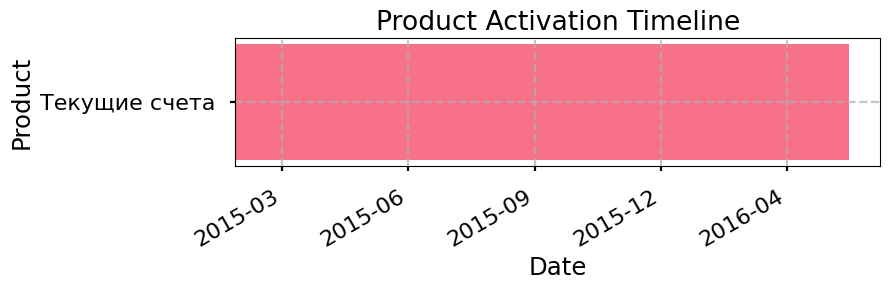

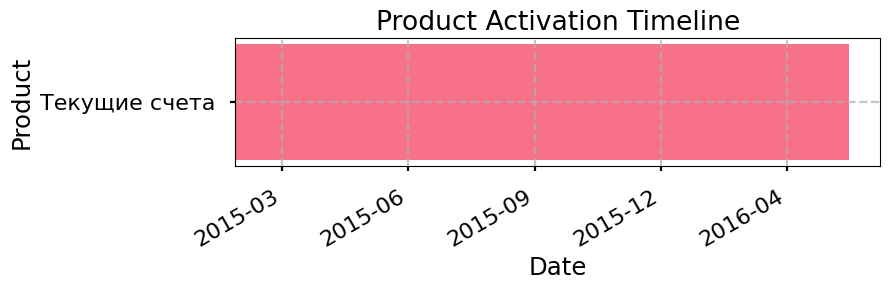

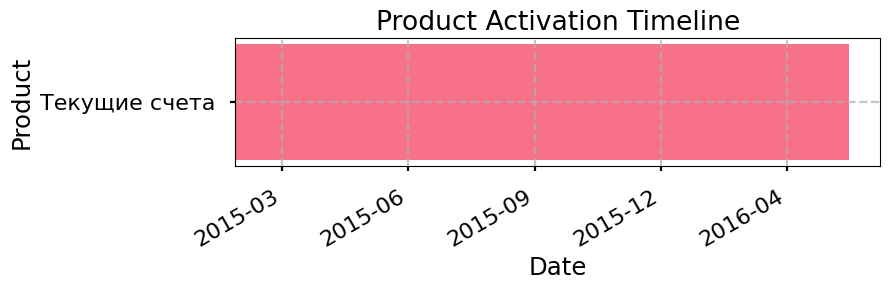

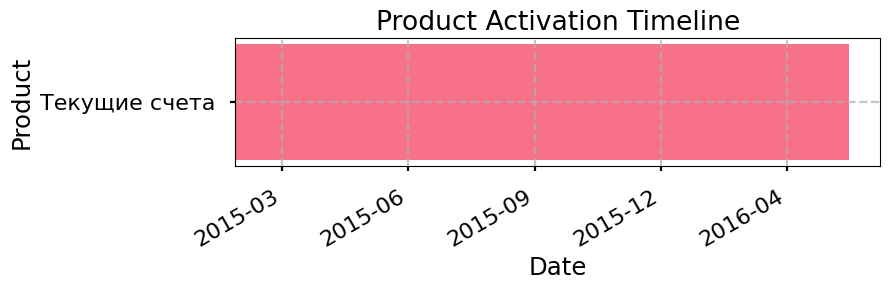

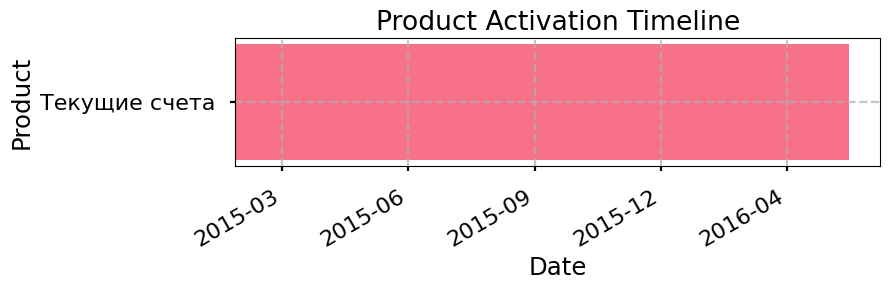

No active products to plot


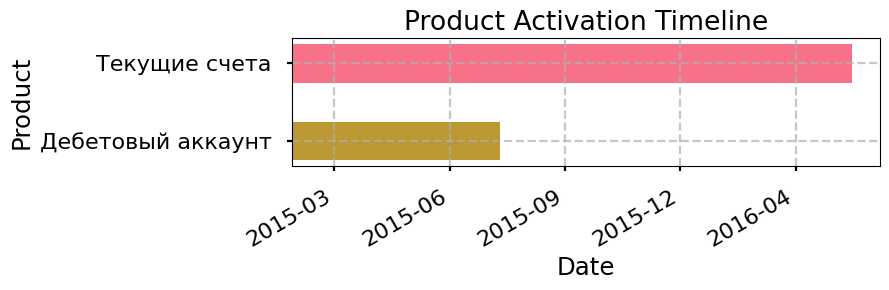

No active products to plot


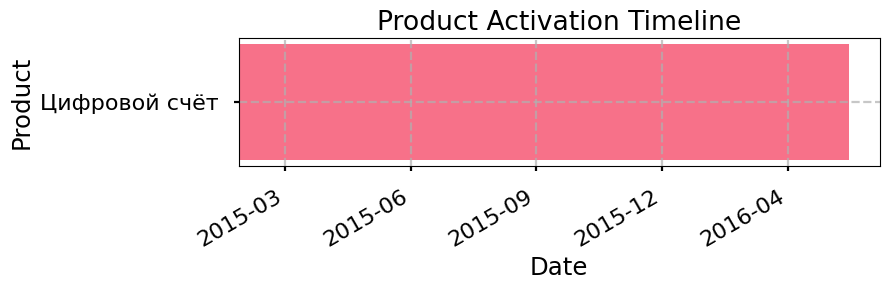

No active products to plot


In [26]:
def get_active_periods(df, products):
    periods = []
    
    for product in products:
        active_dates = df[df[product] == 1]['fecha_dato']
        if not active_dates.empty:
            start = active_dates.min()
            end = active_dates.max()
            periods.append({
                'Product': cool_names_dict[product],
                'Start': start,
                'End': end
            })
    return pd.DataFrame(periods)

def plot_gantt(df, products):
    timeline_df = get_active_periods(df, products)
    
    if timeline_df.empty:
        print("No active products to plot")
        return
    
    fig, ax = plt.subplots(figsize=(9, 3))
    
    # Convert dates to matplotlib date format
    timeline_df['Start_num'] = mdates.date2num(timeline_df['Start'])
    timeline_df['End_num'] = mdates.date2num(timeline_df['End'])
    
    # Create bars for each product
    for i, (_, row) in enumerate(timeline_df.iterrows()):
        duration = row['End_num'] - row['Start_num']
        ax.barh(
            y=row['Product'],
            width=duration,
            left=row['Start_num'],
            height=0.5,
            align='center',
            label=row['Product']
        )
    
    # Format x-axis
    ax.xaxis.set_major_formatter(DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)
    
    # Format y-axis
    ax.set_yticks(timeline_df['Product'])
    ax.set_yticklabels(timeline_df['Product'])
    ax.invert_yaxis()  # reverse order
    
    # Add labels and title
    ax.set_xlabel('Date')
    ax.set_ylabel('Product')
    ax.set_title('Product Activation Timeline')
    
    # Add grid
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Auto format dates
    fig.autofmt_xdate()
    
    plt.tight_layout()
    plt.show()

# Посмотрим динамику обладания продуктами по 10 случайным людям
for id in df['ncodpers'].sample(10):
    one_man = df[df['ncodpers']==id]
    selected_data = one_man[['fecha_dato'] + products].copy()
    # Конвертация в datetime
    selected_data['fecha_dato'] = pd.to_datetime(selected_data['fecha_dato'])
    plot_gantt(selected_data, products)


В продуктовой истории большинство клиентов долго живёт с одним базовым продуктом, чаще всего текущим счётом. Покупка нового продукта — редкое событие, поэтому модель должна решать не только задачу классификации продукта, но и задачу отбора небольшой группы клиентов с повышенной вероятностью покупки.


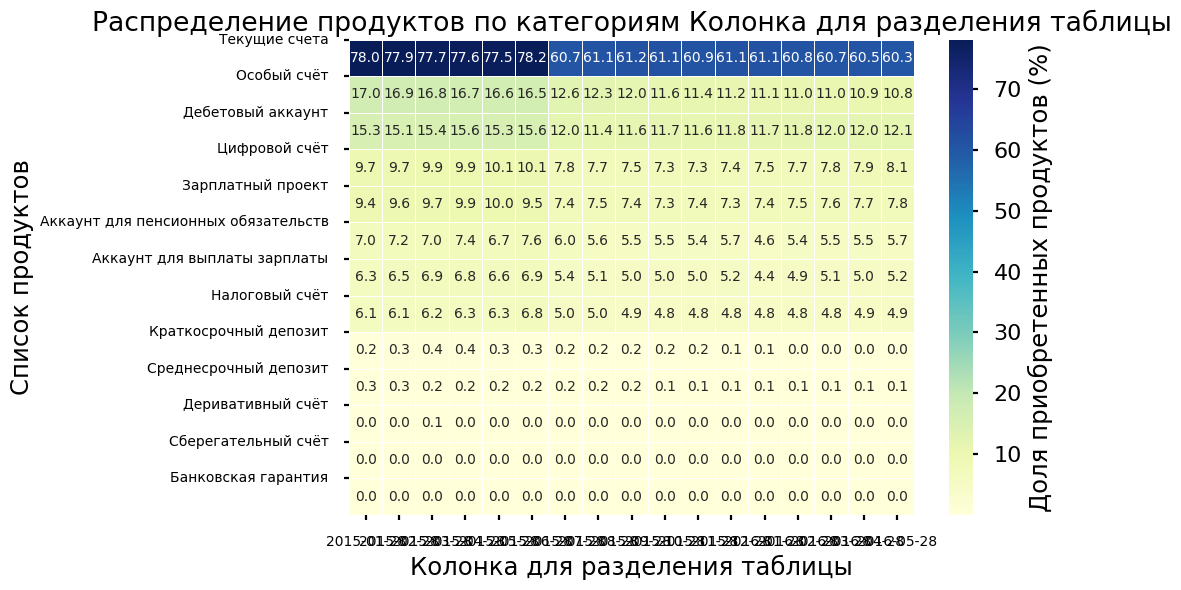

In [27]:
make_heatmap(df, f='fecha_dato', dict=cool_names_dict, products=products+outsiders)

В целом по выборке виден спад доли текущих и особых счетов, тогда как часть нишевых продуктов остаётся почти невостребованной. Для рекомендательной системы это означает, что массовые продукты дают стабильный обучающий сигнал, а редкие продукты лучше объединять или оценивать отдельно.


# Анализ данных и рекомендации для системы рекомендаций

## Общий вывод

Данные достаточно пригодны для построения рекомендательной системы, но требуют устойчивой предобработки: заполнения пропусков, обработки выбросов, сворачивания редких категорий и аккуратной работы с сильным дисбалансом продуктов.

Основные наблюдения:
- около 57.8% клиентов неактивны;
- клиентская база географически и канально сконцентрирована;
- текущий счёт доминирует среди продуктов;
- большинство продуктовых классов редкие, поэтому они объединяются в `other` или требуют отдельной проверки качества.

## Рекомендации для модели

- обучать статистики предобработки только на train-части;
- клиппировать `renta` и `antiguedad`, возраст переводить в интервалы;
- использовать продуктовую историю клиента и число текущих продуктов;
- применять ALS как персональный baseline-признак, но финальное качество оценивать по per-class PR-AUC/lift;
- для редких продуктов отслеживать support и не делать выводы только по высоким lift на малой выборке.

## Итог по качеству

Последний запуск `modeling.ipynb` показывает, что финальный классификатор существенно лучше случайного PR-AUC-бейзлайна: средний PR-AUC по продуктовым классам с ненулевым support равен 0.296 против базовой доли 0.0093, то есть примерно 31.8× выше. Подробности — в `artifacts/classification_report.txt`.


In [33]:
formatted_markdown_content = """\
# Аналитический отчёт по данным и рекомендациям

Документ фиксирует актуальные выводы по EDA и последнему обучающему запуску
`modeling.ipynb`. Подробные численные отчёты лежат в `artifacts/`.

## 1. Данные

Источник — Kaggle Competition **Santander Product Recommendation**,
файл `train_ver2.csv`: 13 647 309 строк и 48 исходных колонок.

Ключевые наблюдения из `eda.ipynb`:

- Пропуски в большинстве колонок невелики, но есть исключения:
  - `conyuemp` практически пустой;
  - `ult_fec_cli_1t` заполнен только для небольшой доли клиентов;
  - `renta` содержит около 20% пропусков и тяжёлый правый хвост.
- Есть аномалии в числовых признаках: возраст до 164 лет, экстремальные доходы,
  отдельные некорректные значения стажа.
- Клиентская база сильно сконцентрирована:
  - около 99.6% клиентов — резиденты Испании;
  - крупнейшие провинции — Madrid и Barcelona;
  - три канала привлечения (`KHE`, `KAT`, `KFC`) дают основную массу клиентов;
  - около 57.8% клиентов неактивны.
- Продуктовое потребление неравномерно: текущий счёт — доминирующий продукт,
  большинство остальных продуктов встречается редко. Это напрямую влияет на
  дисбаланс таргета и выбор метрик.

## 2. Предобработка

В актуальной версии обучение и сервис используют один модуль `preprocessing.py`.
Пайплайн:

1. удаляет малоинформативные признаки;
2. приводит `age`, `antiguedad`, `renta` к числам;
3. заполняет пропуски медианами/модами train-части;
4. переводит возраст и даты в интервалы/когорты;
5. сворачивает редкие категории в `other`;
6. клиппирует экстремальные `renta` и `antiguedad`;
7. добавляет арифметические признаки, агрегаты и `total_products`;
8. добавляет ALS-признак `recommended_product_id`.

Статистики предобработки обучаются только на train и сохраняются в
`fastapi/preprocessing_params.json`, поэтому сервис применяет те же преобразования,
что и обучение.

## 3. Целевая переменная

Модель предсказывает первый продукт, купленный клиентом в 2016 году.
Класс `0` означает отсутствие покупки, `99` — продукт вне шорт-листа.

Шорт-лист продуктов формируется по покупкам 2015 года: отдельными классами остаются
продукты с долей покупок не ниже 1%, максимум 12 продуктов. В последнем прогоне
получены классы:

`0`, `3`, `5`, `8`, `9`, `12`, `13`, `18`, `19`, `20`, `22`, `23`, `24`, `99`.

## 4. Качество рекомендательной системы

Последний отчёт: `artifacts/classification_report.txt`.

| Метрика | Значение |
|---|---:|
| Разбиение | temporal по `fecha_alta`, cutoff `2013-10-09` |
| Train / test | 644 744 / 275 674 объектов |
| CV ROC-AUC macro | 0.9622 |
| ROC-AUC macro OVR на test | 0.9594 |
| Accuracy | 0.9340 |
| Precision macro | 0.3235 |
| Recall macro | 0.3362 |
| F1 macro | 0.2816 |
| PR-AUC macro | 0.3437 |

### Насколько модель лучше бейзлайна

Для accuracy простой бейзлайн — всегда отвечать `no_purchase`. На тесте доля класса
`no_purchase` равна 90.46%, поэтому такой бейзлайн дал бы около **90.46% accuracy**.
Модель даёт **93.40%**, то есть выигрывает **+2.94 п.п.**

Для качества рекомендаций информативнее PR-AUC. У случайного ранжирования PR-AUC
равен доле класса в test. По продуктовым классам с ненулевым support средний PR-AUC
модели равен **0.296**, а средняя доля класса — **0.0093**. Значит, модель примерно
**в 31.8 раза лучше случайного PR-AUC-бейзлайна**.

Примеры lift:

| Продукт | Доля класса | PR-AUC | Lift |
|---|---:|---:|---:|
| `ind_recibo_ult1` | 3.824% | 0.584 | 15.3× |
| `ind_cco_fin_ult1` | 1.252% | 0.502 | 40.1× |
| `ind_nomina_ult1` | 1.306% | 0.413 | 31.7× |
| `ind_ecue_fin_ult1` | 0.991% | 0.296 | 29.9× |
| `ind_cno_fin_ult1` | 0.931% | 0.234 | 25.2× |

Интерпретация: модель хорошо отделяет перспективных клиентов от случайного потока,
но задача остаётся сложной из-за сильного дисбаланса и большого числа клиентов без
покупки. Для бизнес-использования стоит смотреть top-k списки и lift по каждому
продукту, а не только accuracy.

## 5. ALS baseline

ALS оценивается на событиях 2016 года (`artifacts/als_metrics.csv`).

| Scope | Users | precision@5 | recall@5 | hit_rate@5 |
|---|---:|---:|---:|---:|
| Клиенты с историей 2015 и покупками 2016 | 94 091 | 3.18% | 9.60% | 13.36% |
| Все покупатели 2016, включая cold-start | 115 867 | 2.58% | 7.79% | 10.85% |

ALS как самостоятельная система даёт умеренный hit_rate@5, но в финальной модели он
полезен как персональный признак `recommended_product_id`.

## 6. Практические выводы

- Основная ценность модели — ранжирование и приоритизация клиентов/продуктов:
  PR-AUC по продуктам кратно выше случайного бейзлайна.
- Метрики по классу `no_purchase` нельзя считать качеством рекомендаций: этот класс
  доминирует в выборке.
- Редкие продукты требуют осторожной интерпретации: большой lift на маленьком support
  может быть нестабилен.
- Для эксплуатации нужны мониторинг качества входного потока (`/drift`, Prometheus)
  и регулярное переобучение на новых периодах.

"""

with open('recommendations_analysis.md', 'w', encoding='utf-8') as file:
    file.write(formatted_markdown_content)
print('Файл recommendations_analysis.md обновлён')


In [30]:
TRACKING_SERVER_HOST = "127.0.0.1"
TRACKING_SERVER_PORT = 5000

EXPERIMENT_NAME = "Bank_product_Analysis"
RUN_NAME = "eda"

FS_ASSETS = 'analysis'
os.makedirs(FS_ASSETS, exist_ok=True)

# Локальный tracking-сервер MLflow
mlflow.set_tracking_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")
mlflow.set_registry_uri(f"http://{TRACKING_SERVER_HOST}:{TRACKING_SERVER_PORT}")

mlflow.set_experiment(EXPERIMENT_NAME)

2026/09/17 09:22:19 INFO mlflow.tracking.fluent: Experiment with name 'Bank_product_Analysis' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:///E:/Data/OTUS/homework/otus_prj_bank_rec_sys/mlruns_artifacts/1', creation_time=1789626139586, experiment_id='1', last_update_time=1789626139586, lifecycle_stage='active', name='Bank_product_Analysis', tags={}>

In [34]:
with mlflow.start_run():
    with open("recommendations_analysis.md", "w", encoding="utf-8") as f:
        f.write(formatted_markdown_content)

    mlflow.log_artifact("recommendations_analysis.md", artifact_path=FS_ASSETS)

🏃 View run painted-duck-684 at: http://127.0.0.1:5000/#/experiments/1/runs/0da39ecf763f466bb2fa4a53adf715bc
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


Вывод: актуальный аналитический отчёт записан в `recommendations_analysis.md` и залогирован в MLflow как артефакт EDA.
